# Experiment 1 — Evaluation

Visualization-only notebook. All heavy compute runs on Modal; this notebook loads JSON/npz artifacts.

## Download artifacts first

```bash
modal volume get tti-checkpoints eval/expt1_baseline_seed42/ checkpoints/eval/expt1_baseline_seed42/
modal volume get tti-checkpoints eval/expt1_orthogonal_1e-1_seed42/ checkpoints/eval/expt1_orthogonal_1e-1_seed42/
modal volume get tti-checkpoints eval/expt1_orthogonal_1e-2_seed42/ checkpoints/eval/expt1_orthogonal_1e-2_seed42/
modal volume get tti-checkpoints eval/expt1_orthogonal_1e-3_seed42/ checkpoints/eval/expt1_orthogonal_1e-3_seed42/
modal volume get tti-checkpoints eval/expt1_polysemantic_1e-1_seed42/ checkpoints/eval/expt1_polysemantic_1e-1_seed42/
modal volume get tti-checkpoints eval/expt1_polysemantic_1e-2_seed42/ checkpoints/eval/expt1_polysemantic_1e-2_seed42/
modal volume get tti-checkpoints eval/expt1_polysemantic_1e-3_seed42/ checkpoints/eval/expt1_polysemantic_1e-3_seed42/
```

Local deps (if not already installed):
```bash
pip install matplotlib seaborn pandas
```

In [1]:
import json
import os
import sys

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

# Artifact base directory (relative to this notebook)
ARTIFACT_DIR = "../checkpoints/eval"

RUN_NAMES = [
    "expt1_baseline_seed42",
    "expt1_orthogonal_1e-1_seed42",
    "expt1_orthogonal_1e-2_seed42",
    "expt1_orthogonal_1e-3_seed42",
    "expt1_polysemantic_1e-1_seed42",
    "expt1_polysemantic_1e-2_seed42",
    "expt1_polysemantic_1e-3_seed42",
]
RUN_LABELS = {
    "expt1_baseline_seed42":          "Baseline",
    "expt1_orthogonal_1e-1_seed42":   "Orthogonal λ=1e-1",
    "expt1_orthogonal_1e-2_seed42":   "Orthogonal λ=1e-2",
    "expt1_orthogonal_1e-3_seed42":   "Orthogonal λ=1e-3",
    "expt1_polysemantic_1e-1_seed42": "Polysemantic λ=1e-1",
    "expt1_polysemantic_1e-2_seed42": "Polysemantic λ=1e-2",
    "expt1_polysemantic_1e-3_seed42": "Polysemantic λ=1e-3",
}
# Colour palette: baseline grey, orthogonal blues, polysemantic oranges
RUN_COLORS = {
    "expt1_baseline_seed42":          "#555555",
    "expt1_orthogonal_1e-1_seed42":   "#084594",
    "expt1_orthogonal_1e-2_seed42":   "#2171b5",
    "expt1_orthogonal_1e-3_seed42":   "#6baed6",
    "expt1_polysemantic_1e-1_seed42": "#a63603",
    "expt1_polysemantic_1e-2_seed42": "#e6550d",
    "expt1_polysemantic_1e-3_seed42": "#fd8d3c",
}
N_LAYERS = 6


def artifact_path(run_name: str, filename: str) -> str:
    return os.path.join(ARTIFACT_DIR, run_name, filename)


def load_json(run_name: str, filename: str) -> dict:
    path = artifact_path(run_name, filename)
    with open(path) as f:
        return json.load(f)


def load_npz(run_name: str, filename: str):
    return np.load(artifact_path(run_name, filename))


# Only include runs whose artifacts are present on disk
AVAILABLE_RUNS = [r for r in RUN_NAMES if os.path.exists(artifact_path(r, "perplexity.json"))]
print(f"Available runs ({len(AVAILABLE_RUNS)}/{len(RUN_NAMES)}): {AVAILABLE_RUNS}")

Available runs (7/7): ['expt1_baseline_seed42', 'expt1_orthogonal_1e-1_seed42', 'expt1_orthogonal_1e-2_seed42', 'expt1_orthogonal_1e-3_seed42', 'expt1_polysemantic_1e-1_seed42', 'expt1_polysemantic_1e-2_seed42', 'expt1_polysemantic_1e-3_seed42']


## 1. Perplexity

In [2]:
rows = []
for run_name in AVAILABLE_RUNS:
    data = load_json(run_name, "perplexity.json")
    rows.append({
        "Run": RUN_LABELS[run_name],
        "Val Loss": f"{data['val_loss']:.4f}",
        "Perplexity": f"{data['perplexity']:.2f}",
        "Tokens": f"{data['n_tokens']:,}",
        "Batches": data["n_batches"],
    })

df_ppl = pd.DataFrame(rows).set_index("Run")
display(df_ppl)

,Val Loss,Perplexity,Tokens,Batches
Run,,,,
Baseline,1.4598,4.31,"4,653,648",688
Orthogonal λ=1e-1,1.4604,4.31,"4,653,648",688
Orthogonal λ=1e-2,1.4610,4.31,"4,653,648",688
Orthogonal λ=1e-3,1.4610,4.31,"4,653,648",688
Polysemantic λ=1e-1,1.4593,4.30,"4,653,648",688
Polysemantic λ=1e-2,1.4617,4.31,"4,653,648",688
Polysemantic λ=1e-3,1.4603,4.31,"4,653,648",688


## 2. Cosine Similarity Heatmaps

2×6 grid (run × layer) of neuron-neuron cosine similarity matrices, plus a bar chart of mean off-diagonal per layer.

/var/folders/vg/fvxf7b8x2j3cx4tls6qgxdzr0000gn/T/ipykernel_251/2903795923.py:44: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


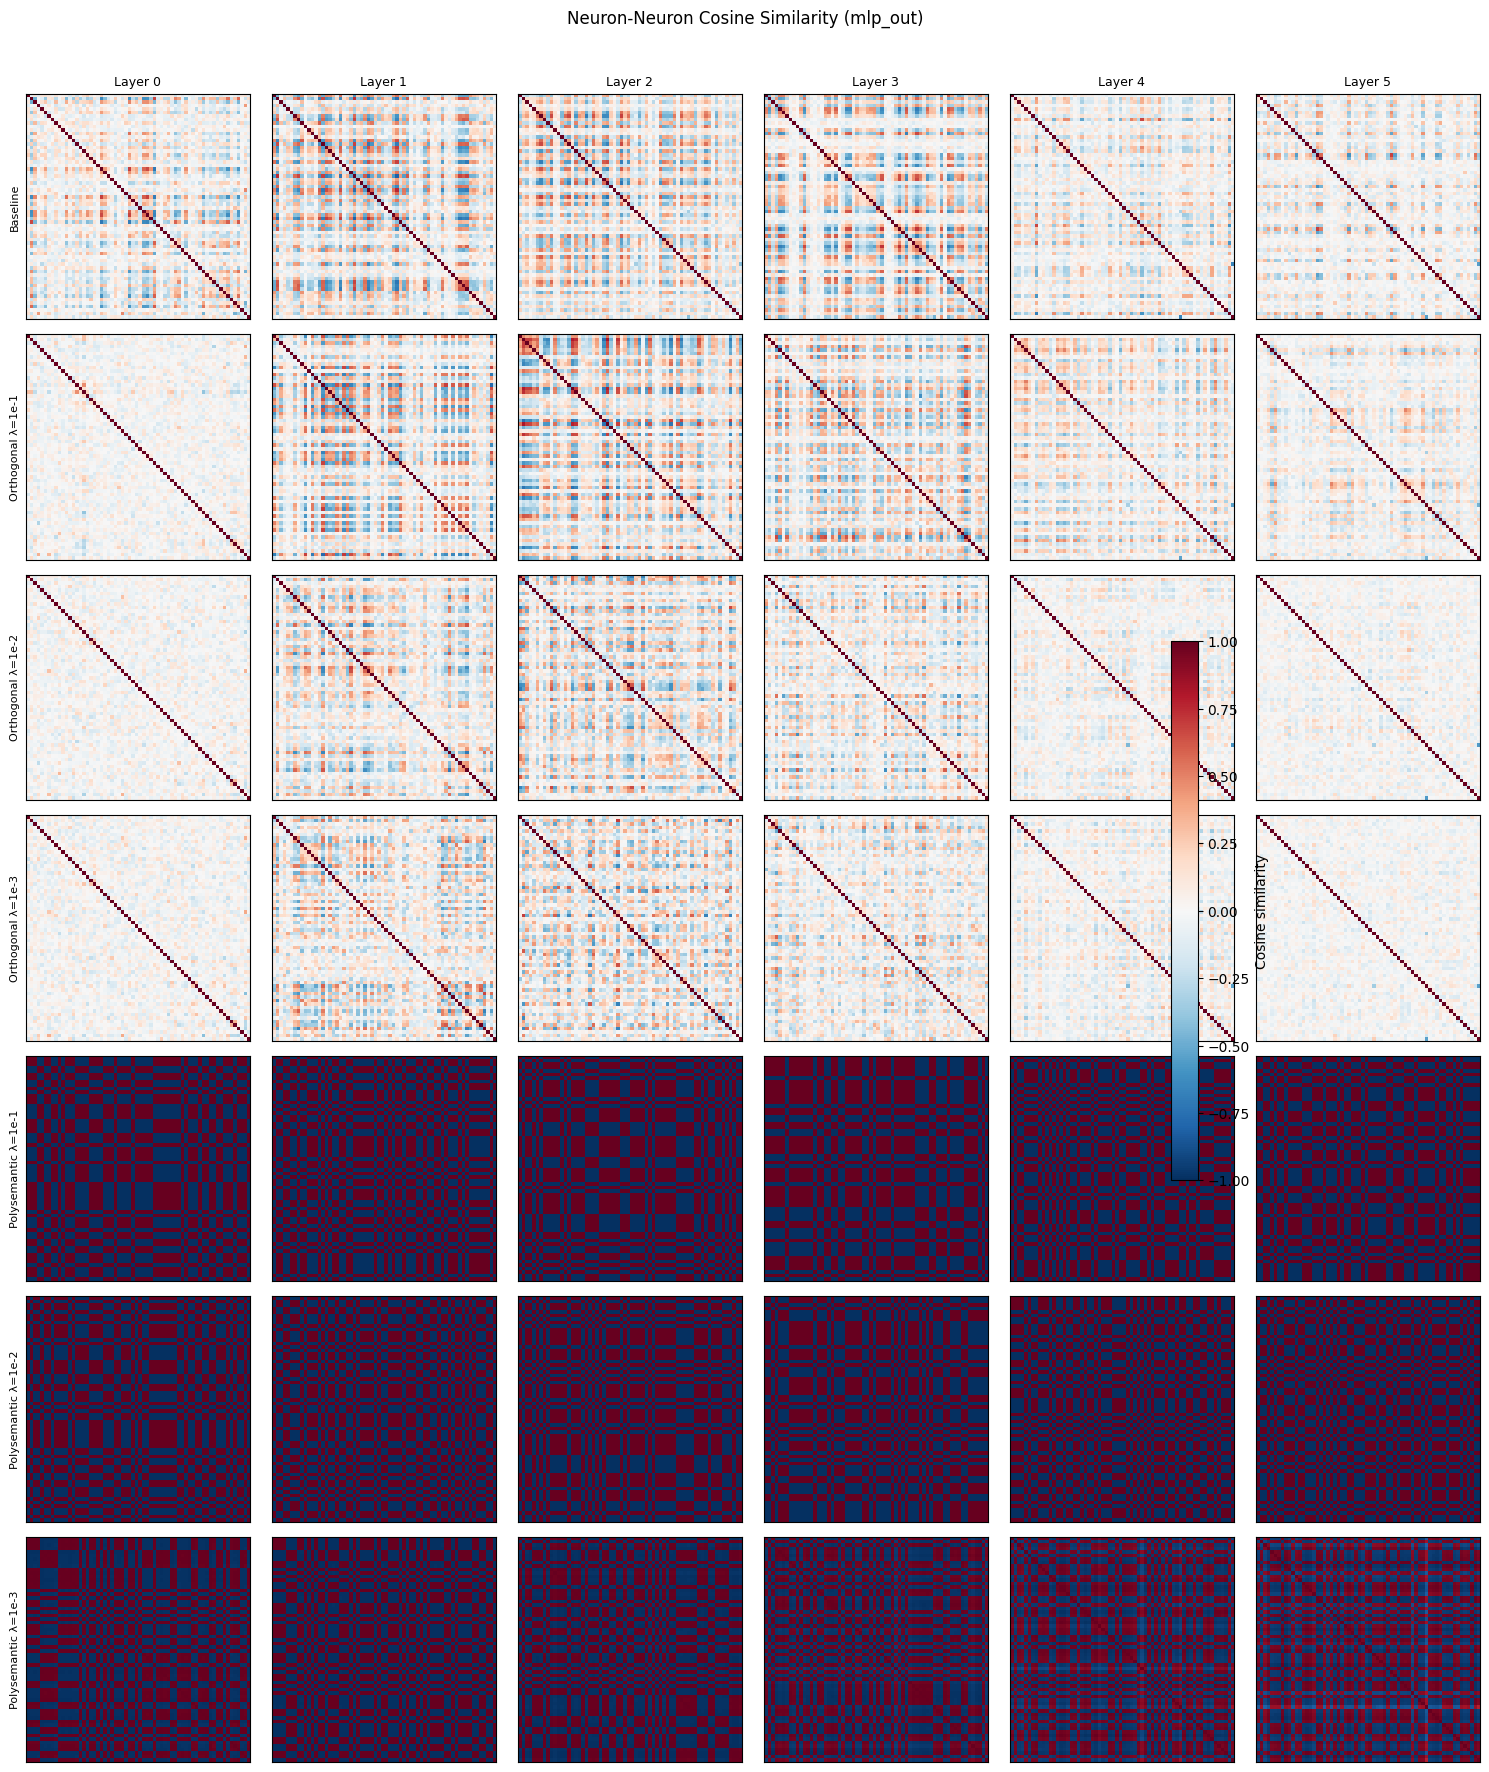

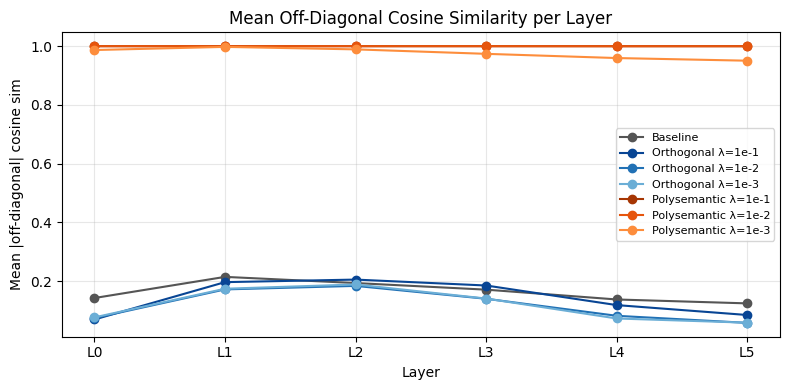

In [3]:
sim_data = {}
mean_off_diag_data = {}

for run_name in AVAILABLE_RUNS:
    npz = load_npz(run_name, "cosine_sim_heatmaps.npz")
    sim_data[run_name] = {int(k.split("_")[1]): npz[k] for k in npz.files}

    mods = {}
    for layer_idx, mat in sim_data[run_name].items():
        D = mat.shape[0]
        mask = ~np.eye(D, dtype=bool)
        mods[layer_idx] = float(np.abs(mat[mask]).mean())
    mean_off_diag_data[run_name] = mods


# --- Grid: runs × layers ---
n_runs = len(AVAILABLE_RUNS)
fig, axes = plt.subplots(
    n_runs, N_LAYERS,
    figsize=(N_LAYERS * 2.5, n_runs * 2.5),
    squeeze=False,
)

for row_idx, run_name in enumerate(AVAILABLE_RUNS):
    for col_idx in range(N_LAYERS):
        ax = axes[row_idx][col_idx]
        if col_idx not in sim_data[run_name]:
            ax.axis("off")
            continue
        mat = sim_data[run_name][col_idx]
        D = mat.shape[0]
        step = max(1, D // 64)
        mat_small = mat[::step, ::step]
        im = ax.imshow(mat_small, vmin=-1, vmax=1, cmap="RdBu_r", aspect="auto")
        if col_idx == 0:
            ax.set_ylabel(RUN_LABELS[run_name], fontsize=8)
        if row_idx == 0:
            ax.set_title(f"Layer {col_idx}", fontsize=9)
        ax.set_xticks([])
        ax.set_yticks([])

fig.suptitle("Neuron-Neuron Cosine Similarity (mlp_out)", fontsize=12, y=1.01)
plt.colorbar(im, ax=axes, shrink=0.4, label="Cosine similarity")
plt.tight_layout()
plt.show()


# --- Line chart: mean off-diagonal per layer ---
fig, ax = plt.subplots(figsize=(8, 4))
for run_name in AVAILABLE_RUNS:
    vals = [mean_off_diag_data[run_name].get(l, 0) for l in range(N_LAYERS)]
    ax.plot(range(N_LAYERS), vals, marker="o", label=RUN_LABELS[run_name],
            color=RUN_COLORS[run_name])

ax.set_xlabel("Layer")
ax.set_ylabel("Mean |off-diagonal| cosine sim")
ax.set_title("Mean Off-Diagonal Cosine Similarity per Layer")
ax.set_xticks(range(N_LAYERS))
ax.set_xticklabels([f"L{i}" for i in range(N_LAYERS)])
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Top-k Activating Contexts per Neuron

In [5]:
topk_data = {run_name: load_json(run_name, "topk_contexts.json") for run_name in AVAILABLE_RUNS}
print("Loaded top-k context data for:", list(topk_data.keys()))

Loaded top-k context data for: ['expt1_baseline_seed42', 'expt1_orthogonal_1e-1_seed42', 'expt1_orthogonal_1e-2_seed42', 'expt1_orthogonal_1e-3_seed42', 'expt1_polysemantic_1e-1_seed42', 'expt1_polysemantic_1e-2_seed42', 'expt1_polysemantic_1e-3_seed42']


In [ ]:
def show_neuron_contexts(run_name: str, layer: int, neuron: int, top_n: int = 5):
    """Display the top-n activating contexts for a given run/layer/neuron."""
    label = RUN_LABELS.get(run_name, run_name)
    entries = topk_data[run_name].get(str(layer), {}).get(str(neuron), [])
    if not entries:
        print(f"No data for {label} layer={layer} neuron={neuron}")
        return

    print(f"\n{'='*60}")
    print(f"Run: {label}  |  Layer: {layer}  |  Neuron: {neuron}")
    print(f"{'='*60}")
    for entry in entries[:top_n]:
        print(f"  Rank {entry['rank']}  activation={entry['activation']:+.4f}")
        print(f"  Context: {entry['context_text'][:200]!r}")
        print()


# Example: compare neuron 0, layer 3 across all available runs
for run_name in AVAILABLE_RUNS:
    show_neuron_contexts(run_name, layer=3, neuron=0, top_n=3)

In [ ]:
# Activation distribution for a given layer/neuron across all runs
LAYER = 3
NEURON = 0

n_runs = len(AVAILABLE_RUNS)
fig, axes = plt.subplots(1, n_runs, figsize=(4 * n_runs, 4), sharey=True)
if n_runs == 1:
    axes = [axes]

for ax, run_name in zip(axes, AVAILABLE_RUNS):
    entries = topk_data[run_name].get(str(LAYER), {}).get(str(NEURON), [])
    acts = [e["activation"] for e in entries]
    if acts:
        colors = [RUN_COLORS[run_name] if a >= 0 else "#cccccc" for a in acts]
        ax.barh(range(len(acts)), acts, color=colors)
        ax.set_yticks(range(len(acts)))
        ax.set_yticklabels([f"Rank {e['rank']}" for e in entries], fontsize=8)
    ax.set_xlabel("Activation")
    ax.set_title(f"{RUN_LABELS[run_name]}\nLayer {LAYER}, Neuron {NEURON}", fontsize=8)
    ax.axvline(0, color="k", linewidth=0.5)

plt.suptitle("Top-k Activation Values", fontsize=12)
plt.tight_layout()
plt.show()

## 4. Linear Probe Results (POS Tags)

In [ ]:
probe_data = {run_name: load_json(run_name, "probe_results.json") for run_name in AVAILABLE_RUNS}

rows = []
for run_name in AVAILABLE_RUNS:
    data = probe_data[run_name]
    for layer_idx in range(N_LAYERS):
        key = str(layer_idx)
        if key in data:
            rows.append({
                "Run": RUN_LABELS[run_name],
                "Layer": layer_idx,
                "Accuracy": data[key]["accuracy"],
                "Macro F1": data[key]["macro_f1"],
            })

df_probes = pd.DataFrame(rows)
print(df_probes.to_string(index=False))

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for run_name in AVAILABLE_RUNS:
    data = probe_data[run_name]
    layers, accs, f1s = [], [], []
    for layer_idx in range(N_LAYERS):
        key = str(layer_idx)
        if key in data:
            layers.append(layer_idx)
            accs.append(data[key]["accuracy"])
            f1s.append(data[key]["macro_f1"])
    kw = dict(marker="o", label=RUN_LABELS[run_name], color=RUN_COLORS[run_name])
    axes[0].plot(layers, accs, **kw)
    axes[1].plot(layers, f1s, **kw)

for ax, title, ylabel in zip(
    axes,
    ["Probe Accuracy by Layer", "Probe Macro F1 by Layer"],
    ["Accuracy", "Macro F1"],
):
    ax.set_xlabel("Layer")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_xticks(range(N_LAYERS))
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Per-class F1 heatmaps — one per run
n_runs = len(AVAILABLE_RUNS)
fig, axes = plt.subplots(1, n_runs, figsize=(7 * n_runs, 6), squeeze=False)

for col_idx, run_name in enumerate(AVAILABLE_RUNS):
    ax = axes[0][col_idx]
    data = probe_data[run_name]
    label_names = data.get("label_names", [])

    mat = np.zeros((N_LAYERS, len(label_names)))
    for layer_idx in range(N_LAYERS):
        key = str(layer_idx)
        if key in data:
            per_class = data[key].get("per_class_f1", {})
            for j, tag in enumerate(label_names):
                mat[layer_idx, j] = per_class.get(tag, 0.0)

    sns.heatmap(
        mat,
        ax=ax,
        xticklabels=label_names,
        yticklabels=[f"L{i}" for i in range(N_LAYERS)],
        vmin=0, vmax=1,
        cmap="YlOrRd",
        annot=True, fmt=".2f",
        linewidths=0.5,
    )
    ax.set_title(f"Per-class F1 — {RUN_LABELS[run_name]}", fontsize=9)
    ax.set_xlabel("POS Tag")
    ax.set_ylabel("Layer")

plt.tight_layout()
plt.show()